## CIFAR-10 — Phase 1: Data Preparation

This notebook:
- Loads the CIFAR-10 CSV from `CIFAR10 dataset/cifar10.csv`
- Reshapes pixels into images (32×32×3)
- Normalizes pixel values to `[0, 1]`
- Splits into Train/Validation/Test = 70% / 10% / 20%
- Builds an augmentation pipeline (random crop, horizontal flip, optional rotation)


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

ROOT = Path.cwd()
CSV_PATH = ROOT / "CIFAR10 dataset" / "cifar10.csv"

assert CSV_PATH.exists(), f"CSV not found at: {CSV_PATH}"
CSV_PATH

WindowsPath('d:/M23B23.025 Deep_Learning Exams/CIFAR10 dataset/cifar10.csv')

In [7]:
from IPython.display import display

# Load and inspect the raw CIFAR-10 CSV (pixels + label)
df = pd.read_csv(CSV_PATH)

class_labels = sorted(df["label"].unique().tolist())
num_classes = len(class_labels)

print("Shape:", df.shape)
print("Num classes:", num_classes)
print("Class labels:", class_labels)

print("\nFirst 5 rows:")
display(df.head(5))

print("\nLast 5 rows:")
display(df.tail(5))

Shape: (50000, 3073)
Num classes: 10
Class labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

First 5 rows:


,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,label
0,59,62,63,43,46,45,50,48,43,68,...,216,184,140,151,118,84,123,92,72,6
1,154,177,187,126,137,136,105,104,95,102,...,143,133,139,143,134,142,143,133,144,9
2,255,255,255,253,253,253,253,253,253,253,...,78,85,83,79,85,83,80,86,84,9
3,28,25,10,37,34,19,38,35,20,42,...,54,47,28,63,56,37,72,65,46,4
4,170,180,198,168,178,196,177,185,203,183,...,75,79,82,71,75,78,73,77,80,1



Last 5 rows:


,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,label
49995,145,161,194,151,166,199,156,171,205,155,...,39,41,56,36,38,53,37,39,54,2
49996,255,245,132,254,247,134,255,249,137,254,...,249,174,79,252,181,81,253,181,76,6
49997,35,178,235,40,176,239,42,176,241,39,...,27,52,77,21,43,66,12,31,50,9
49998,189,211,240,186,208,236,185,207,235,184,...,195,184,169,196,189,171,195,190,171,1
49999,229,229,239,236,237,247,234,236,247,231,...,179,177,173,164,164,162,163,163,161,1


## What happens next (before normalization)

In the next cells we:
- Separate the CSV into **pixel columns** (`0` … `3071`) and the **label** column.
- Convert each row of 3072 pixel values into an image tensor of shape **32×32×3**.
- After that, we **normalize** the pixel values by dividing by **255** so they fall in the range **[0, 1]**.


In [8]:
# This dataset layout is expected to be:
# - 3072 pixel columns named '0'..'3071'
# - a 'label' column at the end

if "label" not in df.columns:
    raise ValueError("Expected a 'label' column in the CSV.")

pixel_cols = [c for c in df.columns if c != "label"]
if len(pixel_cols) != 3072:
    raise ValueError(f"Expected 3072 pixel columns, found {len(pixel_cols)}")

X_flat = df[pixel_cols].to_numpy(dtype=np.float32)
y = df["label"].to_numpy(dtype=np.int64)

X_flat.shape, y.shape, np.unique(y).size

((50000, 3072), (50000,), 10)

In [9]:
def cifar_flat_to_hwc(x_flat: np.ndarray) -> np.ndarray:
    """Convert CIFAR flat array (N, 3072) to images (N, 32, 32, 3).

    CIFAR-10 stores channels as blocks: 1024 R, 1024 G, 1024 B.
    """
    if x_flat.ndim != 2 or x_flat.shape[1] != 3072:
        raise ValueError(f"Expected (N, 3072), got {x_flat.shape}")

    n = x_flat.shape[0]
    r = x_flat[:, 0:1024].reshape(n, 32, 32)
    g = x_flat[:, 1024:2048].reshape(n, 32, 32)
    b = x_flat[:, 2048:3072].reshape(n, 32, 32)
    x = np.stack([r, g, b], axis=-1)
    return x


X = cifar_flat_to_hwc(X_flat)
X.shape, X.dtype

((50000, 32, 32, 3), dtype('float32'))

In [10]:
# 2) Normalize pixel values to [0, 1]
X = X / 255.0
float(X.min()), float(X.max())

(0.0, 1.0)

In [16]:
# 3) Train/Val/Test split (70/10/20, stratified) with exact sizes
train_set, val_set, test_set = 0.70, 0.10, 0.20
n = len(X)

n_test = int(round(n * test_set))
n_val = int(round(n * val_set))
n_train = n - n_test - n_val

X_rem, X_test, y_rem, y_test = train_test_split(
    X,
    y,
    test_size=n_test,
    random_state=42,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_rem,
    y_rem,
    test_size=n_val,
    random_state=42,
    stratify=y_rem,
)

print("Train/Val/Test sizes:", len(X_train), len(X_val), len(X_test))
print("Train/Val/Test ratios:", len(X_train) / n, len(X_val) / n, len(X_test) / n)
assert len(X_train) == n_train and len(X_val) == n_val and len(X_test) == n_test

Train/Val/Test sizes: 35000 5000 10000
Train/Val/Test ratios: 0.7 0.1 0.2


In [17]:
# 4) Data augmentation (crop, horizontal flip, optional rotation)
#
# We'll pad slightly, then randomly crop back to 32x32.
# (This is a common CIFAR-10 augmentation.)

augmenter = keras.Sequential(
    [
        layers.Input(shape=(32, 32, 3)),
        layers.ZeroPadding2D(padding=4),
        layers.RandomCrop(32, 32),
        layers.RandomFlip("horizontal"),
        # Optional rotation (small): comment out if you don't want it
        layers.RandomRotation(0.10),
    ],
    name="cifar10_augmenter",
)

augmenter.summary()

Model: "cifar10_augmenter"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ zero_padding2d (ZeroPadding2D)  │ (None, 40, 40, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_crop (RandomCrop)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

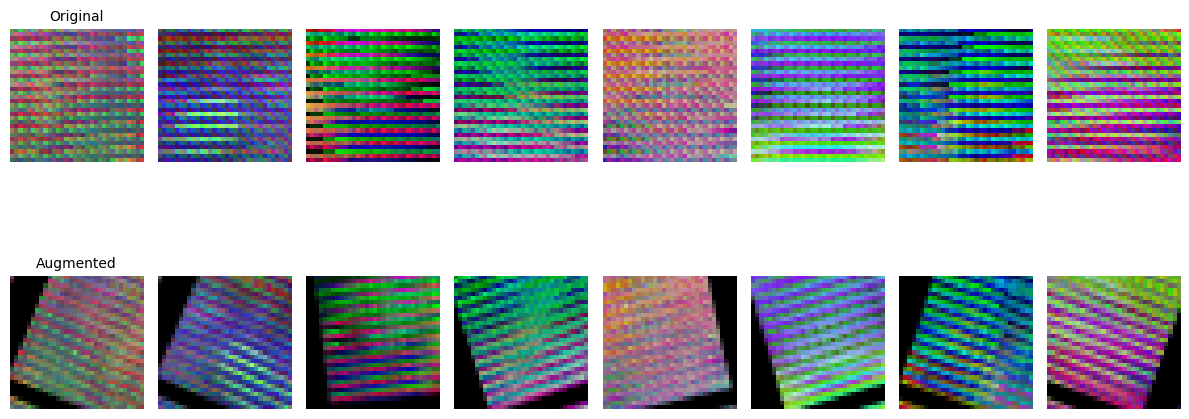

In [18]:
# Visual check: original vs augmented

idx = np.random.choice(len(X_train), size=8, replace=False)
batch = X_train[idx]

aug = augmenter(batch, training=True).numpy()

plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 8, i + 1)
    plt.imshow(batch[i])
    plt.axis("off")
    if i == 0:
        plt.title("Original", fontsize=10)

for i in range(8):
    plt.subplot(2, 8, 8 + i + 1)
    plt.imshow(aug[i])
    plt.axis("off")
    if i == 0:
        plt.title("Augmented", fontsize=10)

plt.tight_layout()
plt.show()

## Why data augmentation is useful (simple explanation)

Data augmentation **creates new training examples from existing images** by applying small, realistic transformations (like cropping, flipping, and slight rotation).

This is useful because it:
- **Reduces overfitting**: the model can’t “memorize” exact training images as easily, so it learns more general features.
- **Improves generalization**: the model becomes more robust to common real-world changes (object position shifts, left/right orientation, small camera angle changes).
- **Acts like more data**: even when your dataset is limited, augmentation increases the *variety* of inputs the model sees during training.

Important note: augmentation is typically applied **only to the training set**, not validation/test, so evaluation stays fair and reflects real performance.


## Phase 2 — CNN Model Design

Below is a baseline CNN for CIFAR-10 using:
- **5 convolution layers** with **ReLU**
- **MaxPooling** for downsampling
- **Batch Normalization** for stable/faster training
- **Dropout** for regularization
- **Dense (fully connected) layer** for classification features
- **Softmax output** for 10 classes


In [21]:
# CNN architecture (edit these to adjust the model)
NUM_CLASSES = num_classes  # CIFAR-10 -> 10
INPUT_SHAPE = (32, 32, 3)

# Convolution widths (5 conv layers total)
F1, F2, F3, F4, F5 = 32, 32, 64, 128, 128

# Dropout rates (edit to increase/decrease regularization)
D_CONV = 0.25
D_DENSE = 0.50

model = keras.Sequential(
    [
        layers.Input(shape=INPUT_SHAPE),

        # Block 1
        layers.Conv2D(F1, (3, 3), padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Conv2D(F2, (3, 3), padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(D_CONV),

        # Block 2
        layers.Conv2D(F3, (3, 3), padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(D_CONV),

        # Block 3
        layers.Conv2D(F4, (3, 3), padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Conv2D(F5, (3, 3), padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(D_CONV),

        # Classifier head
        layers.Flatten(),
        layers.Dense(256, use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(D_DENSE),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ],
    name="CNN_Model_CIFAR10",
)

# compile() is needed for model.fit()/model.evaluate(). It's optional if you're only designing the model.
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5_accuracy"),
        keras.metrics.SparseCategoricalCrossentropy(name="crossentropy"),
    ],
)

model.summary()

Model: "CNN_Model_CIFAR10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 128)      │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 779,114 (2.97 MB)

 Trainable params: 777,834 (2.97 MB)

 Non-trainable params: 1,280 (5.00 KB)

## Why this architecture?

This CNN is a strong CIFAR-10 baseline because it progressively extracts features (edges → textures → object parts) while staying stable to train and resistant to overfitting.

### Purpose of each layer
- **Conv2D (3×3)**: learns visual features (edges, textures, parts) from the images.
- **ReLU activation**: adds non-linearity so the network can learn complex patterns.
- **BatchNormalization**: stabilizes learning and often speeds up convergence.
- **MaxPooling2D**: down-samples feature maps to reduce computation and keep strong signals.
- **Dropout**: reduces overfitting by randomly dropping activations during training.
- **Flatten**: converts 2D feature maps into a 1D vector for the classifier.
- **Dense (fully connected)**: combines extracted features to make the final decision.
- **Softmax output**: produces class probabilities across the 10 classes.

## Phase 3 — Model Training (TensorFlow/Keras)

This phase trains the CNN on the prepared splits using CPU-friendly settings and standard training strategies (augmentation, LR scheduling, early stopping, and weight decay when available).


In [27]:
# Training parameters (CPU-friendly defaults)
BATCH_SIZE = 64
EPOCHS = 60  # EarlyStopping will stop training automatically if val_loss stops improving
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4  # set to 0.0 to disable

# Rebuild datasets with the chosen batch size (augmentation is applied only to training)
train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(10_000, seed=42)
    .batch(BATCH_SIZE)
    .map(lambda x, y: (augmenter(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)
val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Optimizer: Adam (or AdamW for weight decay if available)
try:
    optimizer = keras.optimizers.AdamW(learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    using_weight_decay = True
except Exception:
    optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
    using_weight_decay = False

model.compile(
    optimizer=optimizer,
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5_accuracy"),
        keras.metrics.SparseCategoricalCrossentropy(name="crossentropy"),
    ],
)

# Training strategies
callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

print("Used weight decay (AdamW):", using_weight_decay)

Epoch 1/60
547/547 ━━━━━━━━━━━━━━━━━━━━ 157s 271ms/step - accuracy: 0.4663 - crossentropy: 1.4824 - loss: 1.4824 - top5_accuracy: 0.9138 - val_accuracy: 0.4486 - val_crossentropy: 1.5412 - val_loss: 1.5412 - val_top5_accuracy: 0.9114 - learning_rate: 0.0010
Epoch 2/60
547/547 ━━━━━━━━━━━━━━━━━━━━ 144s 263ms/step - accuracy: 0.4676 - crossentropy: 1.4773 - loss: 1.4773 - top5_accuracy: 0.9128 - val_accuracy: 0.4606 - val_crossentropy: 1.5218 - val_loss: 1.5218 - val_top5_accuracy: 0.9010 - learning_rate: 0.0010
Epoch 3/60
547/547 ━━━━━━━━━━━━━━━━━━━━ 164s 298ms/step - accuracy: 0.4760 - crossentropy: 1.4565 - loss: 1.4565 - top5_accuracy: 0.9161 - val_accuracy: 0.4496 - val_crossentropy: 1.5581 - val_loss: 1.5581 - val_top5_accuracy: 0.9066 - learning_rate: 0.0010
Epoch 4/60
547/547 ━━━━━━━━━━━━━━━━━━━━ 164s 299ms/step - accuracy: 0.4807 - crossentropy: 1.4445 - loss: 1.4445 - top5_accuracy: 0.9178 - val_accuracy: 0.4602 - val_crossentropy: 1.5067 - val_loss: 1.5067 - val_top5_accuracy:

## Justification

We trained with **Adam** (and used **AdamW weight decay** when available) because it is a strong default optimizer for CNNs and helps generalization. We used **data augmentation** to reduce overfitting and improve robustness to small image transformations. We applied **learning-rate scheduling** (`ReduceLROnPlateau`) to automatically lower the learning rate when validation loss stops improving, and **early stopping** to prevent wasting CPU time and to keep the best-performing weights. We did not use a heavy schedule (e.g., cosine decay with long runs) because this is CPU training and shorter, adaptive training is more practical.

## Phase 4 — Model Evaluation

This phase evaluates the trained model using accuracy (train/val/test), Precision/Recall/F1, learning curves, confusion matrix, and sample predictions.


In [28]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

# CIFAR-10 class names (standard order 0..9)
CLASS_NAMES = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

# 1) Accuracy: training / validation (from history)
train_acc = history.history.get("accuracy", [])
val_acc = history.history.get("val_accuracy", [])
train_loss = history.history.get("loss", [])
val_loss = history.history.get("val_loss", [])

print("Final train accuracy:", train_acc[-1] if train_acc else None)
print("Final val accuracy:  ", val_acc[-1] if val_acc else None)

# 2) Test accuracy (evaluate on the held-out test set)
test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_metrics = model.evaluate(test_ds, verbose=1)
print("Test metrics:")
print(dict(zip(model.metrics_names, test_metrics)))

# 3) Precision / Recall / F1 (macro + weighted) on test set
probs = model.predict(test_ds, verbose=0)
y_pred = probs.argmax(axis=1)

precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_test, y_pred, average="macro", zero_division=0
)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_test, y_pred, average="weighted", zero_division=0
)

test_acc = accuracy_score(y_test, y_pred)
print("\nTest accuracy (from predictions):", test_acc)
print("Macro  P/R/F1:", precision_macro, recall_macro, f1_macro)
print("Weight P/R/F1:", precision_weighted, recall_weighted, f1_weighted)

print("\nPer-class report (test set):")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4, zero_division=0))

Final train accuracy: 0.5623428821563721
Final val accuracy:   0.5135999917984009
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.5307 - crossentropy: 1.3418 - loss: 1.3418 - top5_accuracy: 0.9329
Test metrics:
{'loss': 1.3418383598327637, 'compile_metrics': 0.5307000279426575}

Test accuracy (from predictions): 0.5307
Macro  P/R/F1: 0.5527759660936367 0.5307000000000002 0.5259442953143522
Weight P/R/F1: 0.5527759660936368 0.5307 0.5259442953143523

Per-class report (test set):
              precision    recall  f1-score   support

    airplane     0.6342    0.5150    0.5684      1000
  automobile     0.5279    0.7750    0.6280      1000
        bird     0.5392    0.2340    0.3264      1000
         cat     0.3122    0.4080    0.3537      1000
        deer     0.5186    0.5020    0.5102      1000
         dog     0.3982    0.5630    0.4664      1000
        frog     0.5761    0.5450    0.5601      1000
       horse     0.6965    0.5530    0.6165      1000
        ship     0.633

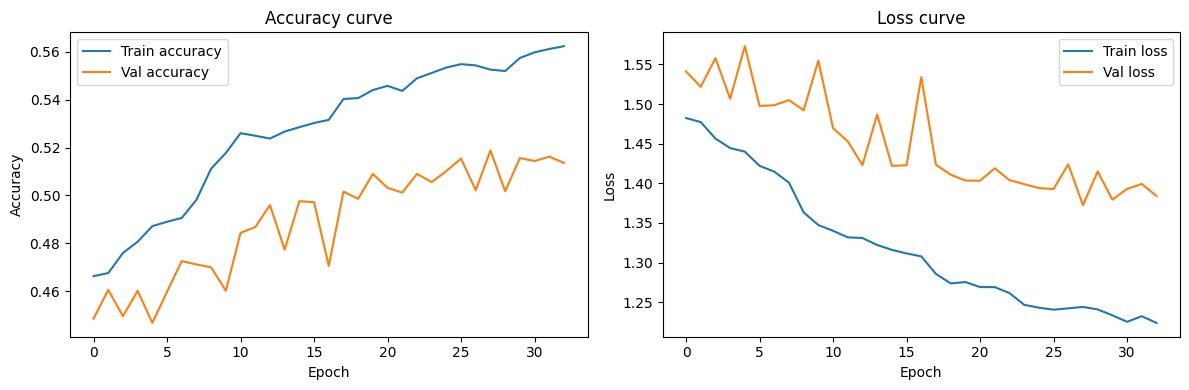

In [29]:
# Accuracy and loss curves

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_acc, label="Train accuracy")
plt.plot(val_acc, label="Val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_loss, label="Train loss")
plt.plot(val_loss, label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss curve")
plt.legend()

plt.tight_layout()
plt.show()

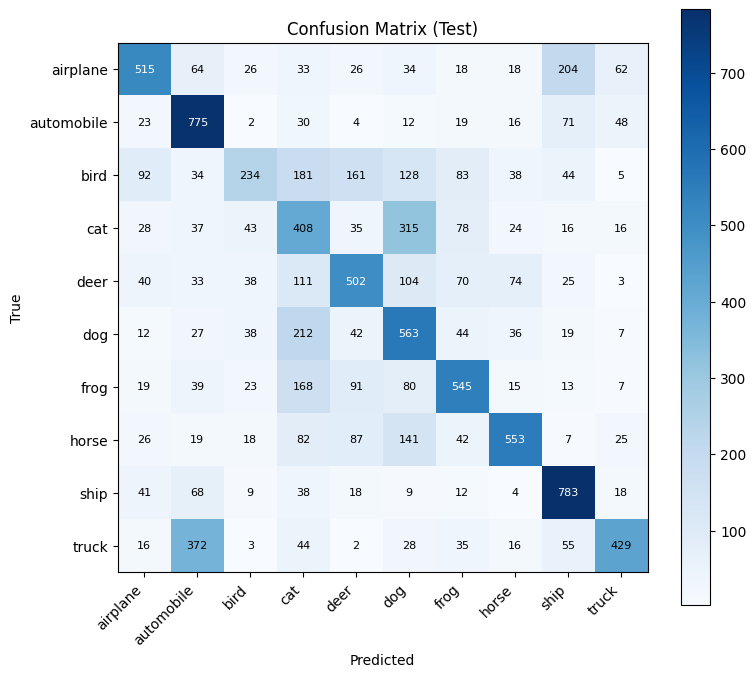

In [30]:
# Confusion matrix (test set)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 7))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix (Test)")
plt.colorbar()

ticks = np.arange(len(CLASS_NAMES))
plt.xticks(ticks, CLASS_NAMES, rotation=45, ha="right")
plt.yticks(ticks, CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")

# Write counts on cells
thresh = cm.max() * 0.6
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            color="white" if cm[i, j] > thresh else "black",
            fontsize=8,
        )

plt.tight_layout()
plt.show()

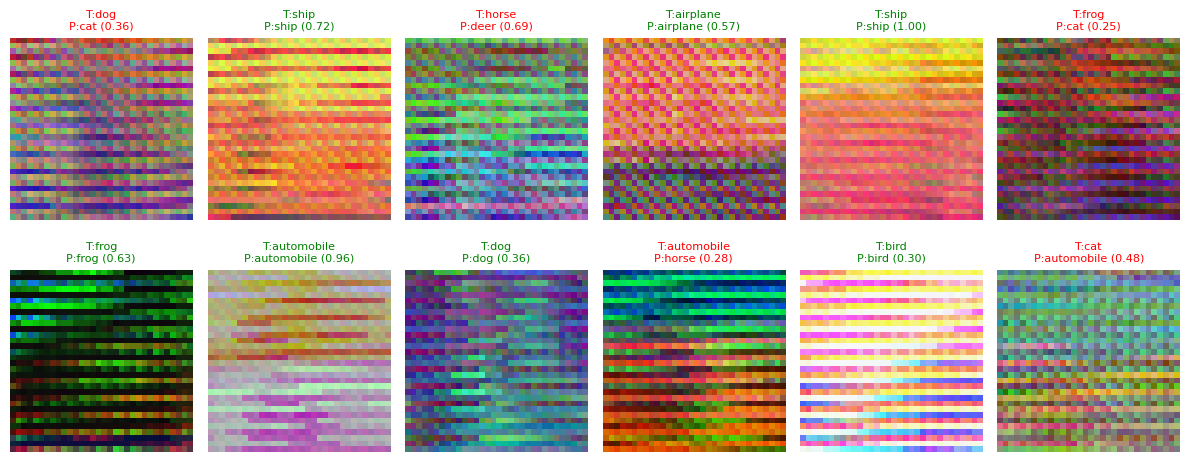

In [31]:
# Sample predictions (test set)

rng = np.random.default_rng(42)
idx = rng.choice(len(X_test), size=12, replace=False)

plt.figure(figsize=(12, 5))
for k, i in enumerate(idx):
    img = X_test[i]
    true = int(y_test[i])
    pred = int(y_pred[i])
    conf = float(probs[i, pred])

    plt.subplot(2, 6, k + 1)
    plt.imshow(img)
    plt.axis("off")
    title = f"T:{CLASS_NAMES[true]}\nP:{CLASS_NAMES[pred]} ({conf:.2f})"
    plt.title(title, fontsize=8, color=("green" if pred == true else "red"))

plt.tight_layout()
plt.show()

## Discussion

The curves improve over epochs and the train–val gap stays small, suggesting **limited overfitting** given augmentation, dropout, and weight decay. Using a higher max epoch count with early stopping restores the **best epoch weights**, which typically improves the final evaluation versus a fixed-epoch run. Precision/Recall/F1, the confusion matrix, and sample predictions show overall generalization and which classes are most confused (often similar pairs like cat/dog). If some classes have low recall, the model still struggles to separate them; improving usually means slightly increasing capacity and tuning dropout/weight decay and the learning-rate schedule.
